In [1]:
library(mlr)
library(tidyverse)

Loading required package: ParamHelpers

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data(titanic_train, package = 'titanic')

In [3]:
?titanic_train

No documentation for ‘titanic_train’ in specified packages and libraries:
you could try ‘??titanic_train’

In [4]:
titanicTib <- as_tibble(titanic_train)

In [5]:
#the passenger will survvie

In [6]:
titanicTib

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S


feature extraction extract the time of day from all the info!

feature creation by combining

feature selection

In [7]:
fctors <- c('Survived','Sex','Pclass')

In [8]:
titanicTib

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S


In [9]:
titanicClean <- (
    titanicTib %>% 
    mutate_at(.vars = fctors, .funs = factor) %>% 
    mutate(FamSize = SibSp + Parch) %>%
    select(Survived, Pclass, Sex, Age, Fare, FamSize)
)

titanicClean

Survived,Pclass,Sex,Age,Fare,FamSize
<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>
0,3,male,22,7.2500,1
1,1,female,38,71.2833,1
1,3,female,26,7.9250,0
1,1,female,35,53.1000,1
0,3,male,35,8.0500,0
0,3,male,NA,8.4583,0
0,1,male,54,51.8625,0
0,3,male,2,21.0750,4
1,3,female,27,11.1333,2


straight line

continuous and discrete categories

multi class classification

linear es continuous los parametros son para saber que tan impotante es el predictor en predecir!

te da mas informacion que solo la clase

feature seleccion

aqui si hay learning

1 / 3720

log odds space something is more likely to occur

predictor es amount of copper y la relacion no es linear entonces hay un problema!

aprende el parametro linear en logg ods space

hay parametros que no tienen poder en log odds space

y hay unos que si y va a estar mas inclinado

log-odds = yintercept + slope * copper

linea es muy probable

es menos probable se resta

en donde se empieza log odds space

1
/
1 + e-z

p = $\frac{1}{1+2.718^{-z}}$

# multinomial logistic regression

|1|2|3|
|---|---|---|
| 1 * 3 | logods probability of being class 0 | the greatest wins |
||logods probability of being class 1||
||logods probability of being class 2||      

| 1 * 3 | logods probability of being class 0 | the greatest wins |
||logods probability of being class 1||
||logods probability of being class 2||      
      

1 * 1 logod
1 * 1

se calculan los logits 

e^logita
/
logita + logitb + logitc

binary logistic regression

sigmoid



In [10]:
gather

function (data, key = "key", value = "value", ..., na.rm = FALSE, 
    convert = FALSE, factor_key = FALSE) 
{
    check_dots_unnamed()
    UseMethod("gather")
}
<bytecode: 0x5ce706384818>
<environment: namespace:tidyr>

In [11]:
titanicUntidy <- gather(titanicClean, key = 'Variable', value = 'Value', -Survived)

Warning message:
“attributes are not identical across measure variables; they will be dropped”


In [12]:
titanicUntidy

Survived,Variable,Value
<fct>,<chr>,<chr>
0,Pclass,3
1,Pclass,1
1,Pclass,3
1,Pclass,1
0,Pclass,3
0,Pclass,3
0,Pclass,1
0,Pclass,3
1,Pclass,3


Warning message:
“The `draw_quantiles` argument of `geom_violin()` is deprecated as of ggplot2
4.0.0.
ℹ Please use the `quantiles.linetype` argument instead.”
Warning message:
“Removed 177 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 177 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


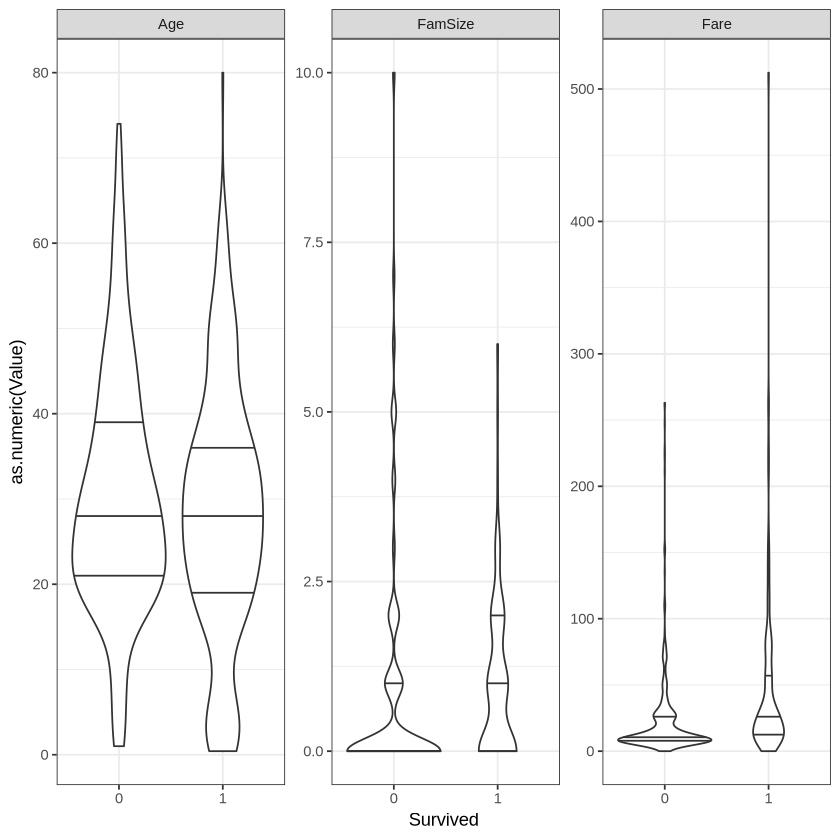

In [13]:
(
    titanicUntidy %>% 
    filter(Variable != 'Pclass' & Variable != 'Sex') %>% 
    ggplot(aes(Survived, as.numeric(Value))) + 
    facet_wrap(~Variable, scales = 'free_y') + 
    geom_violin(draw_quantiles = c(0.25, 0.5, 0.75)) + 
    theme_bw()
)
ggsave("continuous.png")

In [14]:
#se murieron mas los jovenes y los pobres y los que no tenian familia
#sobrevivieron los de la clase 1 y las mujeres

In [15]:
(
    titanicUntidy %>% 
    filter(Variable == 'Pclass' | Variable == 'Sex')
)


Survived,Variable,Value
<fct>,<chr>,<chr>
0,Pclass,3
1,Pclass,1
1,Pclass,3
1,Pclass,1
0,Pclass,3
0,Pclass,3
0,Pclass,1
0,Pclass,3
1,Pclass,3


Saving 6.67 x 6.67 in image


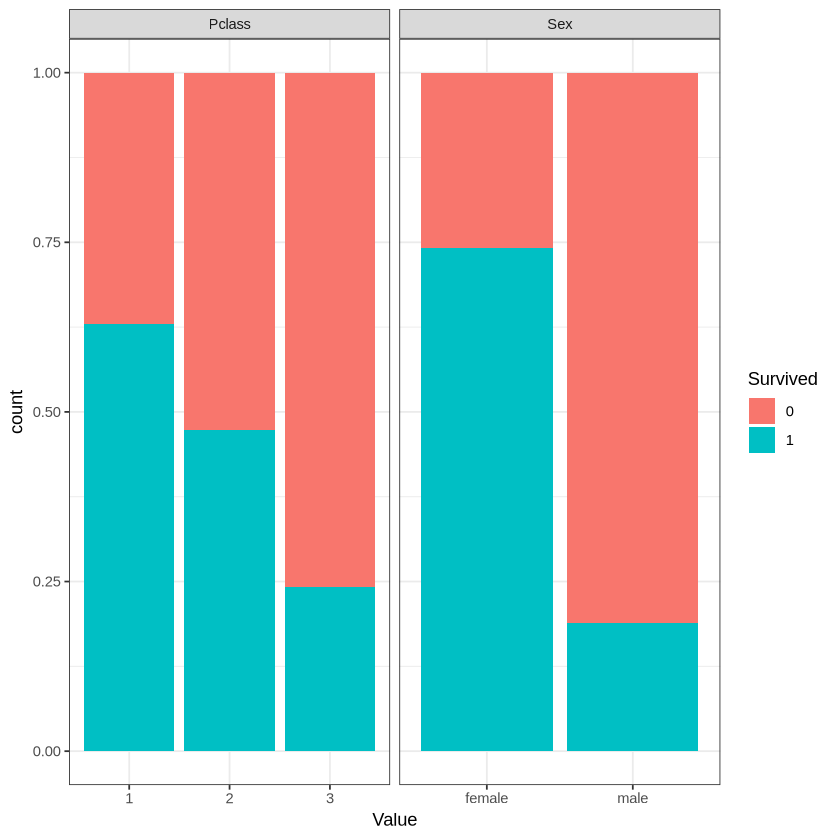

In [16]:
(
    titanicUntidy %>% 
    filter(Variable == 'Pclass' | Variable == 'Sex') %>%
    ggplot(aes(Value, fill = Survived)) + 
    facet_wrap(~Variable, scales = 'free_x') + 
    geom_bar(position = 'fill') + 
    theme_bw()
)

ggsave('discrete.png')

In [17]:
titanicClean$Age

[1] 22.00 38.00 26.00 35.00 35.00    NA 54.00  2.00 27.00 14.00  4.00 58.00
 [13] 20.00 39.00 14.00 55.00  2.00    NA 31.00    NA 35.00 34.00 15.00 28.00
 [25]  8.00 38.00    NA 19.00    NA    NA 40.00    NA    NA 66.00 28.00 42.00
 [37]    NA 21.00 18.00 14.00 40.00 27.00    NA  3.00 19.00    NA    NA    NA
 [49]    NA 18.00  7.00 21.00 49.00 29.00 65.00    NA 21.00 28.50  5.00 11.00
 [61] 22.00 38.00 45.00  4.00    NA    NA 29.00 19.00 17.00 26.00 32.00 16.00
 [73] 21.00 26.00 32.00 25.00    NA    NA  0.83 30.00 22.00 29.00    NA 28.00
 [85] 17.00 33.00 16.00    NA 23.00 24.00 29.00 20.00 46.00 26.00 59.00    NA
 [97] 71.00 23.00 34.00 34.00 28.00    NA 21.00 33.00 37.00 28.00 21.00    NA
[109] 38.00    NA 47.00 14.50 22.00 20.00 17.00 21.00 70.50 29.00 24.00  2.00
[121] 21.00    NA 32.50 32.50 54.00 12.00    NA 24.00    NA 45.00 33.00 20.00
[133] 47.00 29.00 25.00 23.00 19.00 37.00 16.00 24.00    NA 22.00 24.00 19.00
[145] 18.00 19.00 27.00  9.00 36.50 42.00 51.00 22.00 55.50 40.50    NA 51.00
[157] 16.00 30.00    NA    NA 44.00 40.00 26.00 17.00  1.00  9.00    NA 45.00
[169]    NA 28.00 61.00  4.00  1.00 21.00 56.00 18.00    NA 50.00 30.00 36.00
[181]    NA    NA  9.00  1.00  4.00    NA    NA 45.00 40.00 36.00 32.00 19.00
[193] 19.00  3.00 44.00 58.00    NA 42.00    NA 24.00 28.00    NA 34.00 45.50
[205] 18.00  2.00 32.00 26.00 16.00 40.00 24.00 35.00 22.00 30.00    NA 31.00
[217] 27.00 42.00 32.00 30.00 16.00 27.00 51.00    NA 38.00 22.00 19.00 20.50
[229] 18.00    NA 35.00 29.00 59.00  5.00 24.00    NA 44.00  8.00 19.00 33.00
[241]    NA    NA 29.00 22.00 30.00 44.00 25.00 24.00 37.00 54.00    NA 29.00
[253] 62.00 30.00 41.00 29.00    NA 30.00 35.00 50.00    NA  3.00 52.00 40.00
[265]    NA 36.00 16.00 25.00 58.00 35.00    NA 25.00 41.00 37.00    NA 63.00
[277] 45.00    NA  7.00 35.00 65.00 28.00 16.00 19.00    NA 33.00 30.00 22.00
[289] 42.00 22.00 26.00 19.00 36.00 24.00 24.00    NA 23.50  2.00    NA 50.00
[301]    NA    NA 19.00    NA    NA  0.92    NA 17.00 30.00 30.00 24.00 18.00
[313] 26.00 28.00 43.00 26.00 24.00 54.00 31.00 40.00 22.00 27.00 30.00 22.00
[325]    NA 36.00 61.00 36.00 31.00 16.00    NA 45.50 38.00 16.00    NA    NA
[337] 29.00 41.00 45.00 45.00  2.00 24.00 28.00 25.00 36.00 24.00 40.00    NA
[349]  3.00 42.00 23.00    NA 15.00 25.00    NA 28.00 22.00 38.00    NA    NA
[361] 40.00 29.00 45.00 35.00    NA 30.00 60.00    NA    NA 24.00 25.00 18.00
[373] 19.00 22.00  3.00    NA 22.00 27.00 20.00 19.00 42.00  1.00 32.00 35.00
[385]    NA 18.00  1.00 36.00    NA 17.00 36.00 21.00 28.00 23.00 24.00 22.00
[397] 31.00 46.00 23.00 28.00 39.00 26.00 21.00 28.00 20.00 34.00 51.00  3.00
[409] 21.00    NA    NA    NA 33.00    NA 44.00    NA 34.00 18.00 30.00 10.00
[421]    NA 21.00 29.00 28.00 18.00    NA 28.00 19.00    NA 32.00 28.00    NA
[433] 42.00 17.00 50.00 14.00 21.00 24.00 64.00 31.00 45.00 20.00 25.00 28.00
[445]    NA  4.00 13.00 34.00  5.00 52.00 36.00    NA 30.00 49.00    NA 29.00
[457] 65.00    NA 50.00    NA 48.00 34.00 47.00 48.00    NA 38.00    NA 56.00
[469]    NA  0.75    NA 38.00 33.00 23.00 22.00    NA 34.00 29.00 22.00  2.00
[481]  9.00    NA 50.00 63.00 25.00    NA 35.00 58.00 30.00  9.00    NA 21.00
[493] 55.00 71.00 21.00    NA 54.00    NA 25.00 24.00 17.00 21.00    NA 37.00
[505] 16.00 18.00 33.00    NA 28.00 26.00 29.00    NA 36.00 54.00 24.00 47.00
[517] 34.00    NA 36.00 32.00 30.00 22.00    NA 44.00    NA 40.50 50.00    NA
[529] 39.00 23.00  2.00    NA 17.00    NA 30.00  7.00 45.00 30.00    NA 22.00
[541] 36.00  9.00 11.00 32.00 50.00 64.00 19.00    NA 33.00  8.00 17.00 27.00
[553]    NA 22.00 22.00 62.00 48.00    NA 39.00 36.00    NA 40.00 28.00    NA
[565]    NA 24.00 19.00 29.00    NA 32.00 62.00 53.00 36.00    NA 16.00 19.00
[577] 34.00 39.00    NA 32.00 25.00 39.00 54.00 36.00    NA 18.00 47.00 60.00
[589] 22.00    NA 35.00 52.00 47.00    NA 37.00 36.00    NA 49.00    NA 49.00
[601] 24.00    NA    NA 44.00 35.00 36.00 30.00 27.00 22.00 40.00 39.00    NA
[613]    NA    NA 35.00 

In [18]:
sum(is.na(titanicClean$Age))

[1] 177

imputation

In [19]:
imp<-impute(titanicClean, cols = list(Age = imputeMean()))
imp

$data
    Survived Pclass    Sex      Age     Fare FamSize
1          0      3   male 22.00000   7.2500       1
2          1      1 female 38.00000  71.2833       1
3          1      3 female 26.00000   7.9250       0
4          1      1 female 35.00000  53.1000       1
5          0      3   male 35.00000   8.0500       0
6          0      3   male 29.69912   8.4583       0
7          0      1   male 54.00000  51.8625       0
8          0      3   male  2.00000  21.0750       4
9          1      3 female 27.00000  11.1333       2
10         1      2 female 14.00000  30.0708       1
11         1      3 female  4.00000  16.7000       2
12         1      1 female 58.00000  26.5500       0
13         0      3   male 20.00000   8.0500       0
14         0      3   male 39.00000  31.2750       6
15         0      3 female 14.00000   7.8542       0
16         1      2 female 55.00000  16.0000       0
17         0      3   male  2.00000  29.1250       5
18         1      2   male 29.69912  13.

In [20]:
imp$data

Survived,Pclass,Sex,Age,Fare,FamSize
<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>
0,3,male,22.00000,7.2500,1
1,1,female,38.00000,71.2833,1
1,3,female,26.00000,7.9250,0
1,1,female,35.00000,53.1000,1
0,3,male,35.00000,8.0500,0
0,3,male,29.69912,8.4583,0
0,1,male,54.00000,51.8625,0
0,3,male,2.00000,21.0750,4
1,3,female,27.00000,11.1333,2


In [21]:
sum(is.na(titanicClean$Age))

[1] 177

In [22]:
sum(is.na(imp$data$Age))

[1] 0

In [23]:
titanictask <- makeClassifTask(data = imp$data, target = 'Survived')

In [24]:
logreg <- makeLearner('classif.logreg', predict.type = 'prob')

In [25]:
logregmodel <- train(logreg, titanictask)

In [26]:
#we should cross validate our entire 
logregwrapper<-makeImputeWrapper(
    'classif.logreg', 
    cols = list(Age = imputeMean())
)

logregwrapper

Learner classif.logreg.imputed from package stats
Type: classif
Name: ; Short name: 
Class: ImputeWrapper
Properties: twoclass,numerics,factors,prob,weights,missings
Predict-Type: response
Hyperparameters: model=FALSE


In [27]:
#va a variar de mean of the training set

kFold <- makeResampleDesc(
    method = 'RepCV', 
    folds = 10, 
    reps = 50, 
    stratify = TRUE)


In [28]:
logregwithimpute<-resample(
    logregwrapper, 
    titanictask, 
    resampling = kFold, 
    measures = list(acc, fpr, fnr)
)

Resampling: repeated cross-validation

Measures:             acc       fpr       fnr       

[Resample] iter 1:    0.7528090 0.3529412 0.1818182 

[Resample] iter 2:    0.8333333 0.2571429 0.1090909 

[Resample] iter 3:    0.8202247 0.3529412 0.0727273 

[Resample] iter 4:    0.7865169 0.3235294 0.1454545 

[Resample] iter 5:    0.7977528 0.2352941 0.1818182 

[Resample] iter 6:    0.8000000 0.3142857 0.1272727 

[Resample] iter 7:    0.7640449 0.2941176 0.2000000 

[Resample] iter 8:    0.7159091 0.4411765 0.1851852 

[Resample] iter 9:    0.8314607 0.1176471 0.2000000 

[Resample] iter 10:   0.8202247 0.2352941 0.1454545 

[Resample] iter 11:   0.7640449 0.3142857 0.1851852 

[Resample] iter 12:   0.8089888 0.3529412 0.0909091 

[Resample] iter 13:   0.8876404 0.1176471 0.1090909 

[Resample] iter 14:   0.8202247 0.2352941 0.1454545 

[Resample] iter 15:   0.7303371 0.2941176 0.2545455 

[Resample] iter 16:   0.8539326 0.2352941 0.0909091 

[Resample] iter 17:   0.8426966 0.2941176 0

In [29]:
logregwithimpute

Resample Result
Task: imp$data
Learner: classif.logreg.imputed
Aggr perf: acc.test.mean=0.7962104,fpr.test.mean=0.2983950,fnr.test.mean=0.1448788
Runtime: 7.52317

In [34]:
#model performance in the context of my particular problem
logregmodeldata <- getLearnerModel(logregmodel)

In [37]:
#log odds units
coef(logregmodeldata)

(Intercept)      Pclass2      Pclass3      Sexmale          Age         Fare 
 3.809661697 -1.000344806 -2.132428850 -2.775928255 -0.038822458  0.003218432 
     FamSize 
-0.243029114

In [45]:
exp(
    cbind(
        odds_ration = coef(logregmodeldata), 
        confint(logregmodeldata)
    )
)

Waiting for profiling to be done...



,odds_ration,2.5 %,97.5 %
(Intercept),45.13516691,19.14718874,109.72483921
Pclass2,0.36775262,0.20650392,0.65220841
Pclass3,0.11854901,0.06700311,0.20885220
Sexmale,0.06229163,0.04182164,0.09116657
Age,0.96192148,0.94700049,0.97652950
Fare,1.00322362,0.99872001,1.00863263
FamSize,0.78424868,0.68315465,0.89110044


In [53]:
#la clase base son mujeres
1/0.06229 #men were 16.7 more likely to die than women

[1] 16.05394

In [52]:
#continuous
#1.27 times less likely to survive if you add one more member family
#la reference level es pclass1?

#la clase base es la clase 1
1/0.36 #more likely to die los de la clase 2 que los de la clase 1
1/0.1185 #more likely to die los de las clase 3 que los de la clase 1

[1] 2.777778

[1] 8.438819

In [55]:
data(titanic_test, package = 'titanic')

In [58]:
titanicnew<-as_tibble(titanic_test)

In [73]:
titanicnewclean<-(
    titanicnew %>% 
    mutate_at(.vars = c('Sex','Pclass'), .funs = factor) %>%
    mutate(FamSize = SibSp + Parch) %>%
    select(Pclass,Sex,Age,Fare,FamSize)
)

In [77]:
predict(logregmodel, newdata = titanicnewclean)

Warning message in predict.WrappedModel(logregmodel, newdata = titanicnewclean):
“Provided data for prediction is not a pure data.frame but from class tbl_df, hence it will be converted.”


Prediction: 418 observations
predict.type: prob
threshold: 0=0.50,1=0.50
time: 0.00
     prob.0     prob.1 response
1 0.9178036 0.08219636        0
2 0.5909570 0.40904305        0
3 0.9123303 0.08766974        0
4 0.8927383 0.10726167        0
5 0.4069407 0.59305933        1
6 0.8337609 0.16623907        0
... (#rows: 418, #cols: 3)

In [79]:
#the classes are linearly separable